
# Illustrations for chapter 6 of the lecture notes "Pricing and hedging of financial derivatives



In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime,timedelta
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from scipy.stats import norm
from scipy.special import gamma

In [ ]:
# Read the data
df = pd.read_csv("quotedata.dat",skiprows=2)
S0 = 3567.73
# SPX options from cboe.com downloaded on 20/11/2020
curve = [0.09,0.09,0.07,0.10,0.11,0.16,0.21,0.38,0.62,0.83,1.33,1.53]
mcurve = [1./12,2./12,3./12,6./12,1.,2.,3.,5.,7.,10.,20.,30.]
# Treasury yield curve from treasury.gov
# downloaded on 20/11/2020
def ycurve(t):
    return np.interp(t,mcurve,curve)*0.01

In [ ]:
df

,Expiration Date,Calls,Last Sale,Net,Bid,Ask,Vol,IV,Delta,Gamma,...,Puts,Last Sale.1,Net.1,Bid.1,Ask.1,Vol.1,IV.1,Delta.1,Gamma.1,Open Int.1
0,11/20/2020,SPX201120C00100000,3469.89,0.00,0.0,0.0,0,0.0000,0.0000,0.0000,...,SPX201120P00100000,0.0,0.0,0.0,0.00,0,0.0000,0.0000,0.0000,601
1,11/20/2020,SPXW201120C00100000,0.00,0.00,3465.3,3470.2,0,0.0200,0.0000,0.0000,...,SPXW201120P00100000,0.0,0.0,0.0,0.05,0,0.0200,0.0000,0.0000,0
2,11/20/2020,SPX201120C00200000,0.00,0.00,0.0,0.0,0,0.0000,0.0000,0.0000,...,SPX201120P00200000,0.0,0.0,0.0,0.00,0,0.0000,0.0000,0.0000,152
3,11/20/2020,SPXW201120C00200000,0.00,0.00,3365.3,3370.2,0,0.0200,0.0000,0.0000,...,SPXW201120P00200000,0.0,0.0,0.0,0.05,0,0.0200,0.0000,0.0000,95
4,11/20/2020,SPX201120C00300000,0.00,0.00,0.0,0.0,0,0.0000,0.0000,0.0000,...,SPX201120P00300000,0.0,0.0,0.0,0.00,0,0.0000,0.0000,0.0000,1558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8933,12/16/2022,SPX221216C05300000,23.99,-0.91,21.3,24.9,2,0.1769,0.0653,0.0001,...,SPX221216P05300000,0.0,0.0,1791.6,1829.70,0,0.1560,-0.9558,0.0001,31
8934,12/16/2022,SPX221216C05400000,0.00,0.00,19.0,22.6,0,0.1791,0.0591,0.0001,...,SPX221216P05400000,0.0,0.0,1888.2,1926.40,0,0.1539,-0.9645,0.0001,0
8935,12/16/2022,SPX221216C05500000,0.00,0.00,17.0,20.4,0,0.1811,0.0534,0.0001,...,SPX221216P05500000,0.0,0.0,1985.0,2023.40,0,0.1505,-0.9728,0.0001,0
8936,12/16/2022,SPX221216C05700000,0.00,0.00,13.6,17.0,0,0.1851,0.0441,0.0001,...,SPX221216P05700000,0.0,0.0,2179.4,2218.00,0,0.1331,-0.9893,0.0000,0


In [ ]:
df['wdet'] = df['Calls'].apply(lambda s:(s[:4]=='SPXW')) # A flag for weekly options
expdates = df['Expiration Date'].drop_duplicates().to_list()
expdates = expdates[1:] # drop the first zero maturity
dates_list = [datetime.strptime(date, '%m/%d/%Y').date() for date in expdates]
start_date = datetime.strptime("11/20/2020","%m/%d/%Y").date()
matu = [(date-start_date).days/365.25 for date in dates_list]# Compute maturity in years
r = ycurve(matu) # Compute interest rate for each maturity
smiles = [] # implied volatility
vsmiles = [] # dimensionless implied variance
moneyness = []
for i in range(len(expdates)):
    dfi = df[df['Expiration Date']==expdates[i]]
    if(sum(dfi['wdet'])<len(dfi)): # if there are regular options
        dfi = dfi[dfi['wdet']==0] # we filter out the weekly ones
    dfi = dfi[dfi['Vol']+dfi['Vol.1']>0] # filter nonzero volume
    mnn = [np.log(K/S0)-r[i]*matu[i] for K in dfi['Strike'].to_list()] # compute moneyness
    iv = dfi['IV'].to_list() # implied vol for calls
    iv1 = dfi['IV.1'].to_list() # implied vol for puts
    ivol = [iv[i]*(mnn[i]>0)+iv1[i]*(mnn[i]<=0)for i in range(len(iv))] # we use OTM options
    smiles.append(ivol)
    vsmiles.append([vol*vol*matu[i] for vol in ivol])
    moneyness.append(mnn)

In [ ]:
from scipy.optimize import minimize
def svi(k,a,b,rho,m,sig):
    return a+b*(rho*(k-m)+np.sqrt((k-m)**2+sig**2))
def svierr(param,vsmile,moneyness):
    return np.sum((vsmile-svi(moneyness,param[0],param[1],param[2],param[3],param[4]))**2)
def calib(param0,vsmile,moneyness): # calibrate svi for a given maturity
    vvec = np.array(vsmile)
    mvec = np.array(moneyness)
    res =  minimize(lambda param:svierr(param,vvec,mvec),param0)
    csmile = svi(mvec,res.x[0],res.x[1],res.x[2],res.x[3],res.x[4])
    return res.x, res.fun, csmile

In [ ]:
# Fit the SVI model for each maturity
# Attention, we do not check for positivity of parameters
csmiles = []
params = []
for i in range(len(expdates)):
    param, fun, csmile = calib([0.01,0.2,0,0,0.1],vsmiles[i],moneyness[i])
    params.append(param)
    csmiles.append(csmile)



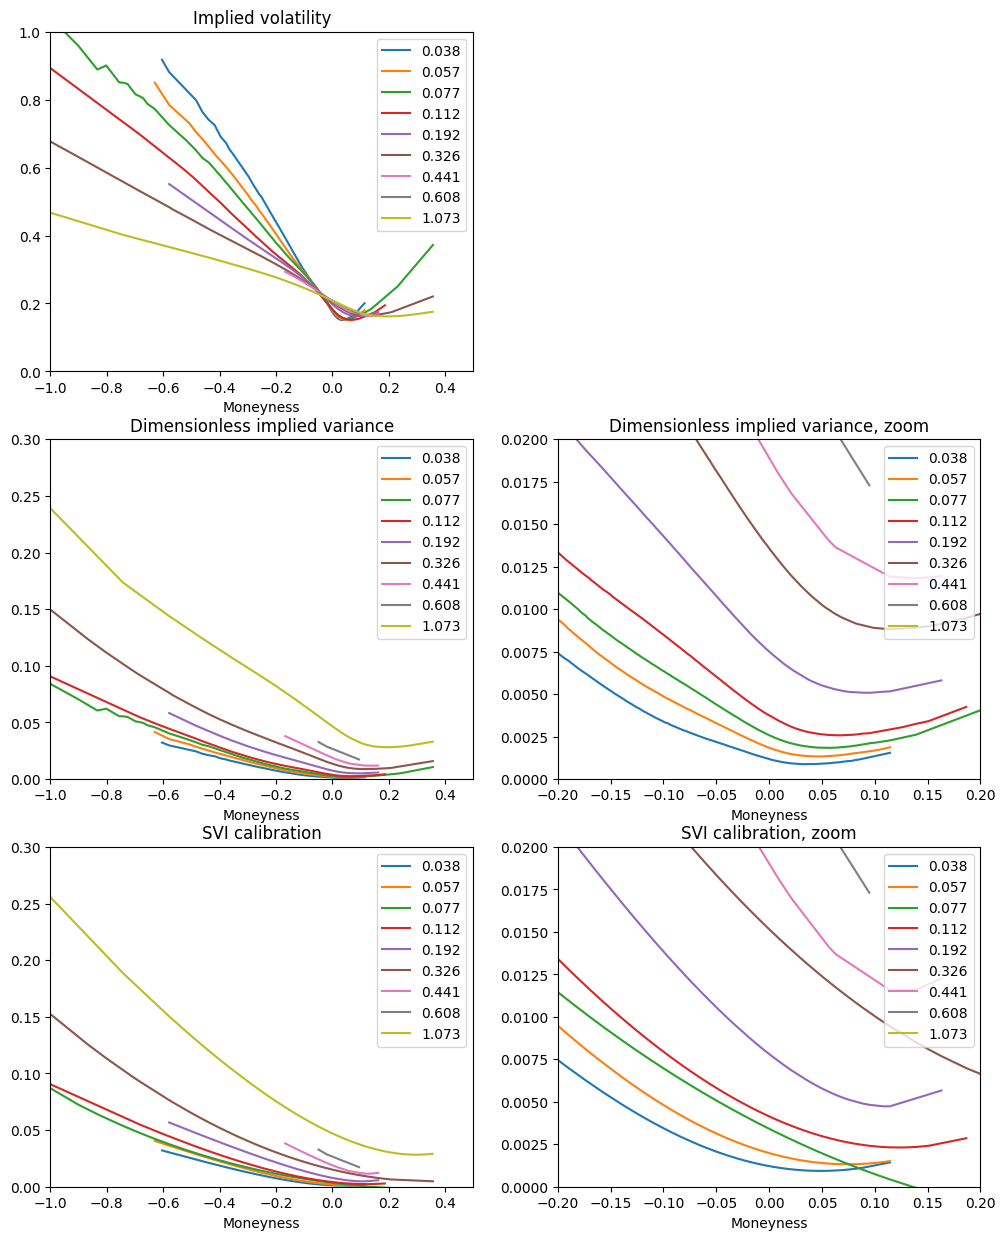

In [ ]:
plt.figure(figsize=(12,15))
plt.subplot(321)
for i in range(5,len(expdates),3):
    plt.plot(moneyness[i],smiles[i],label="{:.3f}".format(matu[i]))
plt.xlim([-1,0.5])
plt.ylim([0,1])
plt.title('Implied volatility')
plt.xlabel('Moneyness')
plt.legend()
plt.subplot(323)
for i in range(5,len(expdates),3):
    plt.plot(moneyness[i],vsmiles[i],label="{:.3f}".format(matu[i]))
plt.xlim([-1,0.5])
plt.ylim([0,0.3])
plt.title('Dimensionless implied variance')
plt.xlabel('Moneyness')
plt.legend()
plt.subplot(324)
for i in range(5,len(expdates),3):
    plt.plot(moneyness[i],vsmiles[i],label="{:.3f}".format(matu[i]))
plt.xlim([-0.2,0.2])
plt.ylim([0,0.02])
plt.title('Dimensionless implied variance, zoom')
plt.xlabel('Moneyness')
plt.legend()
plt.subplot(325)
for i in range(5,len(expdates),3):
    plt.plot(moneyness[i],csmiles[i],label="{:.3f}".format(matu[i]))
plt.xlim([-1,0.5])
plt.ylim([0,0.3])
plt.title('SVI calibration')
plt.xlabel('Moneyness')
plt.legend()
plt.subplot(326)
for i in range(5,len(expdates),3):
    plt.plot(moneyness[i],csmiles[i],label="{:.3f}".format(matu[i]))
plt.xlim([-0.2,0.2])
plt.ylim([0,0.02])
plt.title('SVI calibration, zoom')
plt.xlabel('Moneyness')
plt.legend()



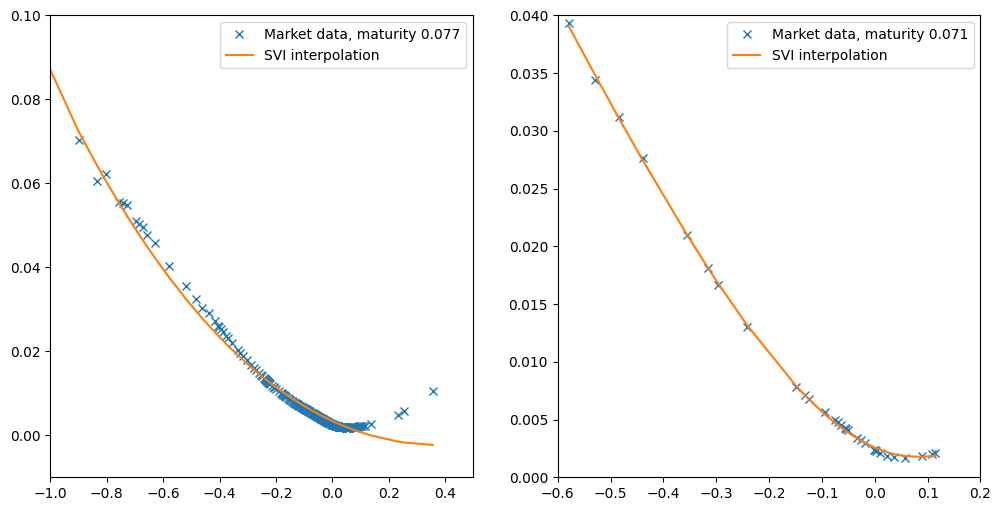

In [ ]:
# Test the quality of SVI fit
plt.figure(figsize=(12,6))
i=11
plt.subplot(121)
plt.plot(moneyness[i],vsmiles[i],'x',label="Market data, maturity {:.3f}".format(matu[i]))
plt.plot(moneyness[i],csmiles[i],label='SVI interpolation')
plt.xlim([-1,0.5])
plt.ylim([-0.01,0.1])
plt.legend()
i=10
plt.subplot(122)
plt.plot(moneyness[i],vsmiles[i],'x',label="Market data, maturity {:.3f}".format(matu[i]))
plt.plot(moneyness[i],csmiles[i],label='SVI interpolation')
plt.xlim([-0.6,0.2])
plt.ylim([-0.0,0.04])
plt.legend()

In [ ]:
params[11]

array([-1.75239713,  0.69413719, -0.69008053, -2.94255496,  3.48363982])

In [ ]:
# Interpolate the implied variance
from scipy.interpolate import interp1d

mins = np.array([min(s) for s in moneyness])
maxs = np.array([max(s) for s in moneyness])
ind = np.where((mins<-0.3)&(maxs>0.1))[0]
imatu = [matu[i] for i in ind]
mon = np.linspace(-.3,.1,101)
mat = np.linspace(0.1,1,100)
ivar = np.zeros((len(ind),len(mon)))
i2var = np.zeros((len(mat),len(mon)))
for i in range(len(ind)):
    i1d = interp1d(moneyness[ind[i]],csmiles[ind[i]],kind='quadratic')
    ivar[i,:] = i1d(mon)
for i in range(len(mon)):
    i1d = interp1d(imatu,ivar[:,i],kind='quadratic')
    i2var[:,i] = i1d(mat)

# Compute the local volatility
dvx = (i2var[1:-1,2:]-i2var[1:-1,:-2])/2./(mon[1]-mon[0])
d2vx = (i2var[1:-1,2:]+i2var[1:-1,:-2]-2*i2var[1:-1,1:-1])/(mon[1]-mon[0])**2
dvt = (i2var[2:,1:-1]-i2var[:-2,1:-1])/2./(mat[1]-mat[0])
mon2 = np.dot(np.ones((len(mat)-2,1)),np.resize(mon[1:-1],(1,len(mon)-2)))
vv = i2var[1:-1,1:-1]
vloc = dvt/((1.-mon2/2./vv*dvx)**2+0.5*d2vx-0.25/vv*dvx**2-1./16*dvx**2)

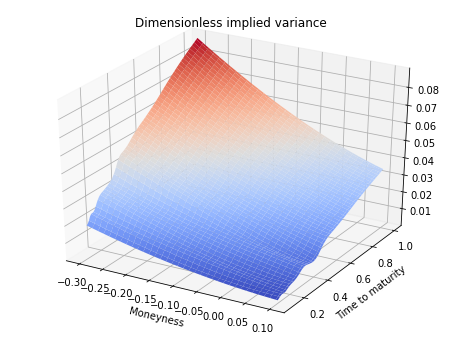

In [ ]:
# Plot the implied variance surface

from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

fig = plt.figure(figsize=(8,6))
ax = fig.gca(projection='3d')
plt.title('Dimensionless implied variance')
plt.xlabel('Moneyness')
plt.ylabel('Time to maturity')
# Make data.
X, Y = np.meshgrid(mon, mat)
# Plot the surface.
surf = ax.plot_surface(X, Y, i2var, cmap=cm.coolwarm)


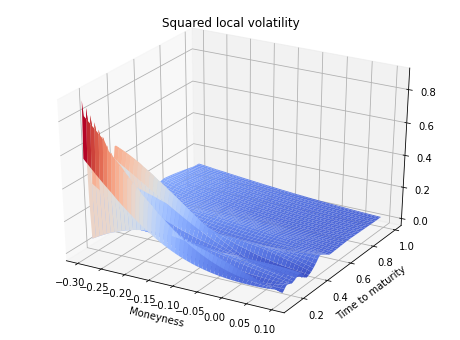

In [ ]:
# Plot the local volatility surface
fig = plt.figure(figsize=(8,6))
ax = fig.gca(projection='3d')

plt.title('Squared local volatility')
plt.xlabel('Moneyness')
plt.ylabel('Time to maturity')
# Make data.
X, Y = np.meshgrid(mon[1:-1], mat[1:-1])
# Plot the surface.
surf = ax.plot_surface(X, Y, vloc, cmap=cm.coolwarm)



In [ ]:
from google.colab import files
uploaded = files.upload()

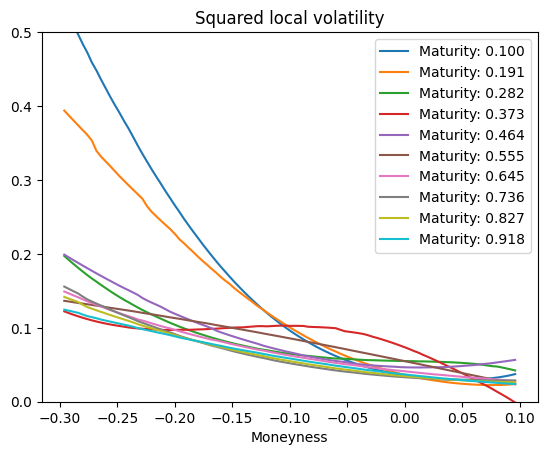

In [ ]:
plt.title('Squared local volatility')
for i in range(0,98,10):
  plt.plot(mon[1:-1],vloc[i,:],label="Maturity: {:.3f}".format(mat[i]))
  plt.xlabel('Moneyness')
  plt.legend()
  plt.ylim([0,0.5])

array([0.1       , 0.10909091, 0.11818182, 0.12727273, 0.13636364,
       0.14545455, 0.15454545, 0.16363636, 0.17272727, 0.18181818,
       0.19090909, 0.2       , 0.20909091, 0.21818182, 0.22727273,
       0.23636364, 0.24545455, 0.25454545, 0.26363636, 0.27272727,
       0.28181818, 0.29090909, 0.3       , 0.30909091, 0.31818182,
       0.32727273, 0.33636364, 0.34545455, 0.35454545, 0.36363636,
       0.37272727, 0.38181818, 0.39090909, 0.4       , 0.40909091,
       0.41818182, 0.42727273, 0.43636364, 0.44545455, 0.45454545,
       0.46363636, 0.47272727, 0.48181818, 0.49090909, 0.5       ,
       0.50909091, 0.51818182, 0.52727273, 0.53636364, 0.54545455,
       0.55454545, 0.56363636, 0.57272727, 0.58181818, 0.59090909,
       0.6       , 0.60909091, 0.61818182, 0.62727273, 0.63636364,
       0.64545455, 0.65454545, 0.66363636, 0.67272727, 0.68181818,
       0.69090909, 0.7       , 0.70909091, 0.71818182, 0.72727273,
       0.73636364, 0.74545455, 0.75454545, 0.76363636, 0.77272